# **Softmax Regression**

What we have learned so far in case of multi-class classification will not work properly in case of when we are dealing with 5 or 6 or 7 classes of classification. Hence we need **Softmax Regression**.

Its also called as **Multinomial Logistic Regression**.

# Definition: Softmax Regression

**Softmax Regression** (also known as Multinomial Logistic Regression) is a supervised machine learning algorithm that generalizes standard Logistic Regression to handle **multi-class classification** problems. While binary Logistic Regression is used when there are exactly two classes (e.g., Spam vs. Not Spam), Softmax Regression is used when there are three or more mutually exclusive classes (e.g., Cat vs. Dog vs. Bird).

### Core Concept
Instead of predicting a single probability for one class, Softmax Regression computes a score for *every* possible class and then converts these scores into a **probability distribution** using the Softmax function. The model assigns the data point to the class with the highest predicted probability.

### Key Mathematical Components
1.  **Linear Scores (Logits):** For a given input $x$, the model calculates a separate linear score ($z_k = w_k^T x + b_k$) for each class $k$.
2.  **The Softmax Function:** It takes the raw scores ($z$) for all classes and "squashes" them into probabilities that range between 0 and 1, and crucially, **sum up to 1.0**. 
    The probability that an input $x$ belongs to class $j$ is calculated as:
    $$P(y=j|x) = \frac{e^{z_j}}{\sum_{k=1}^{K} e^{z_k}}$$
    *(where $K$ is the total number of classes)*
3.  **Cross-Entropy Loss:** The model learns by minimizing the cross-entropy loss, which penalizes the model when the predicted probability distribution diverges from the actual true labels (one-hot encoded).

---

### Summary Table

| Property | Description |
| :--- | :--- |
| **Type** | Supervised Learning (Multi-Class Classification) |
| **Target Variable** | Categorical (3 or more mutually exclusive classes) |
| **Output** | A Probability Distribution across all classes (sums to 1) |
| **Decision Boundary** | Linear (Multiple hyperplanes intersecting) |
| **Loss Function** | Categorical Cross-Entropy |

### Common Use Cases
*   **Image Classification:** Identifying the main object in an image (e.g., MNIST digit recognition: 0 through 9).
*   **Natural Language Processing:** Predicting the next word in a sentence from a vocabulary of thousands of words.
*   **Sentiment Analysis:** Classifying a review as strictly "Positive," "Neutral," or "Negative."


### Softmax Regression

Softmax Regression (also known as Multinomial Logistic Regression) is a generalization of Logistic Regression used for multi-class classification problems where the classes are mutually exclusive.

#### 1. The Softmax Function
The softmax function takes a vector $z$ of $K$ real numbers and normalizes it into a probability distribution consisting of $K$ probabilities proportional to the exponentials of the input numbers.
$$\sigma(z)_i = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}} \text{, for } i = 1, \dots, K$$

Where 
- $K$ = number of classes
- $z$ = input vector of scores (logits) for each class
- $e^{z_i}$ = exponential of the score for class $i$
- $\sum_{j=1}^{K} e^{z_j}$ = normalization term (sum of the exponentials of all scores)
- mathematical constant $e$ (Euler's number), which is approximately equal to $2.71828$ [the value of $e$ is always equal to 2.718]

#### 2. Hypothesis Function
The model outputs a vector of estimated probabilities for each class:
$$h_\theta(x) = \begin{bmatrix} P(y=1 | x; \theta) \\ P(y=2 | x; \theta) \\ \vdots \\ P(y=K | x; \theta) \end{bmatrix} = \frac{1}{\sum_{j=1}^K e^{\theta_j^T x}} \begin{bmatrix} e^{\theta_1^T x} \\ e^{\theta_2^T x} \\ \vdots \\ e^{\theta_K^T x} \end{bmatrix}$$

#### 3. Cost Function: Cross-Entropy Loss
To train the model, we minimize the Categorical Cross-Entropy loss:
$$J(\theta) = -\frac{1}{m} \sum_{i=1}^m \sum_{k=1}^K \mathbb{1}\{y^{(i)} = k\} \log(P(y^{(i)} = k | x^{(i)}; \theta))$$
where $\mathbb{1}\{\cdot\}$ is the indicator function.

#### 4. Key Characteristics
- **Output:** A probability distribution (values between 0 and 1, summing to 1).
- **Decision Rule:** The predicted class is $\hat{y} = \arg\max_k P(y=k|x)$.
- **Relationship:** When $K=2$, Softmax Regression reduces to standard Logistic Regression.


### **Working of softmax regression**


Imagine a neural network trying to classify an image into 3 categories: Cat, Dog, and Bird. The final layer outputs these raw scores (logits):
*   **Cat:** 2.0
*   **Dog:** 1.0
*   **Bird:** 0.1
#### Step 1: Exponentiation (The "Soft" Part)
We raise $e$ to the power of each score. This amplifies the differences and ensures all values are positive:
*   $e^{2.0} \approx 7.39$
*   $e^{1.0} \approx 2.72$
*   $e^{0.1} \approx 1.11$
#### Step 2: Summing
We find the total sum of these exponentiated values:
*   $7.39 + 2.72 + 1.11 = \mathbf{11.22}$
#### Step 3: Normalization
We divide each individual exponentiated score by the total sum to get probabilities:
*   **Cat:** $7.39 / 11.22 = \mathbf{0.66}$ (66%)
*   **Dog:** $2.72 / 11.22 = \mathbf{0.24}$ (24%)
*   **Bird:** $1.11 / 11.22 = \mathbf{0.10}$ (10%)

**Final Check:** $0.66 + 0.24 + 0.10 = 1.0$ (100%).


---
### Why is Softmax so important?
1.  **Probability Interpretation:** It allows us to say, "The model is 66% sure this is a cat," which is much more useful than just seeing a raw score of 2.0.
2.  **Differentiability:** Because it uses the exponential function, it is "smooth" and differentiable. This allows the model to learn using Backpropagation.
3.  **The "Max" in Softmax:** It acts like a "soft" version of the `argmax` function. It doesn't just pick the winner; it highlights the winner while still acknowledging the other possibilities.

# If logistic is for two classes, then when i apply logistic to iris which has 4 classes, then how it works ???

If standard Logistic Regression is mathematically locked into only comparing 2 things at once (Outputting 0 or 1), how does `scikit-learn`'s `LogisticRegression()` effortlessly handle the Iris dataset which has 3 classes (Setosa, Versicolor, Virginica)?

The answer is a trick called **One-vs-Rest (OvR)** (also known as One-vs-All).

Because the standard algorithm physically cannot look at 3 classes at once, `scikit-learn` cheats. Under the hood, it splits the problem up and actually **trains three completely separate binary Logistic Regression models.**

### How the OvR trick works on Iris:

**Model 1 is trained to ask:**
*   `"Is this flower a Setosa? (Yes=1) OR is it literally anything else? (No=0)"`
*   *(It temporarily groups Versicolor and Virginica together into one giant "Not Setosa" category).*

**Model 2 is trained to ask:**
*   `"Is this flower a Versicolor? (1) OR is it literally anything else? (0)"`

**Model 3 is trained to ask:**
*   `"Is this flower a Virginica? (1) OR is it literally anything else? (0)"`

### How It Makes a Final Prediction
When you ask the final model to predict a new, unknown flower, `scikit-learn` silently passes that flower's data through all three independent binary models.

1.  **Model 1** outputs its Sigmoid probability: `82% chance it is Setosa.`
2.  **Model 2** outputs its Sigmoid probability: `12% chance it is Versicolor.`
3.  **Model 3** outputs its Sigmoid probability: `31% chance it is Virginica.`

Now, `scikit-learn` just looks at the three separate scores, picks the highest one (`82%`), and confidently tells you, **"The predicted class is Setosa."**

---

### The Problem with OvR (And Why Softmax is Better)
The problem with the OvR trick is that the probabilities are calculated independently. Notice how in the example above, the probabilities added up to **125%** (`82 + 12 + 31`), not 100%. 

**Softmax Regression** (which `scikit-learn` will actually use automatically if you pass `multi_class='multinomial'` to your LogisticRegression model) fixes this flaw. It trains one single, massive model that directly compares all 3 classes against each other mathematically at the exact same time, guaranteeing the final probabilities perfectly add up to exactly 100%.


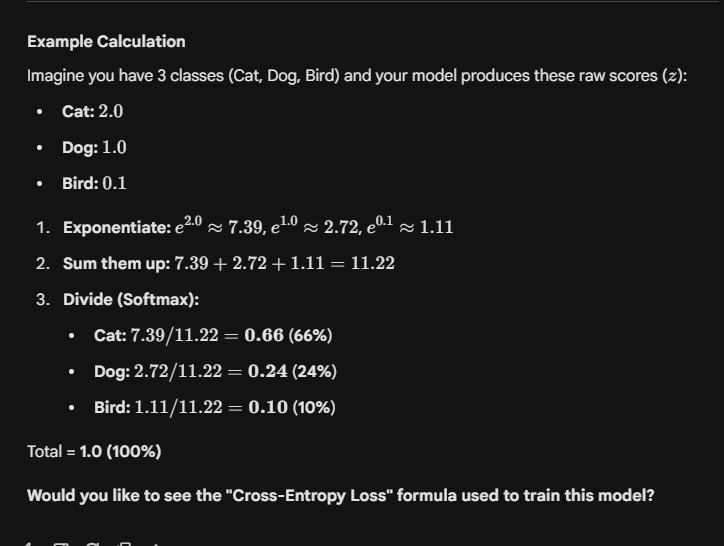